# Aspect-Based Sentiment Analysis & Opinion Mining (Advanced)
## CDS6344 Social Media Computing - Restaurant Review Analysiss

### 7 Aspect Categories:
1. **Food** - Dishes, taste, flavor, cuisine
2. **Service** - Staff, waiter, hospitality
3. **Waiting Time** - Wait, queue, delay, speed
4. **Ambience** - Atmosphere, decor, lighting, music
5. **Cleanliness** - Clean, hygiene, toilet
6. **Price** - Cost, value, bill
7. **Location** - Parking, access, convenient

### Features:
- Proper dependency parsing for (Target, Opinion_Expression, Sentiment) triplets
- Negation handling ("not good", "not fresh")
- Platform comparison (Google Reviews vs TripAdvisor)
- Comprehensive visualizations & summaries

## Part 1: Setup and Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from collections import defaultdict, Counter
import os
from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import opinion_lexicon
import nltk
import warnings
warnings.filterwarnings('ignore')

nltk.download('vader_lexicon', quiet=True)
nltk.download('opinion_lexicon', quiet=True)
nltk.download('punkt', quiet=True)

try:
    nlp = spacy.load('en_core_web_sm')
except:
    print('Downloading spaCy model...')
    import os
    os.system('python -m spacy download en_core_web_sm')
    nlp = spacy.load('en_core_web_sm')

sia = SentimentIntensityAnalyzer()
print('✓ All libraries loaded')

✓ All libraries loaded


In [2]:
# Read raw data
master_dir = os.path.dirname(os.getcwd())

processed_reviews = os.path.join(master_dir, "data", "processed_data", "feature_engineered_reviews.csv")

df = pd.read_csv(processed_reviews)

df.head()

,Review_ID,Review,Rating,Lemmatized_Tokens,Review_lemmatized,Platform,Restaurant,Sentiment_Label
0,R000001,food is taste good and the environment also no...,3.0,"['food', 'taste', 'good', 'environment', 'also...",food taste good environment also not bad . how...,Google,Tandoor Grill,Neutral
1,R000002,our family celebrated birthday on last weekend...,1.0,"['family', 'celebrate', 'birthday', 'last', 'w...",family celebrate birthday last weekend think 5...,Tripadvisor,Latest Recipe,Negative
2,R000003,pretty nice nonya food but very commercial alr...,3.0,"['pretty', 'nice', 'nonya', 'food', 'but', 've...",pretty nice nonya food but very commercial alr...,Google,Madam Kwan's Suria KLCC,Neutral
3,R000004,"food was not on point, the seafood was frozen,...",2.0,"['food', 'not', 'point', ',', 'seafood', 'froz...","food not point , seafood frozen , seasoning , ...",Google,Mercat Barcelona Gastrobar (1MontKiara),Negative
4,R000005,personaly for me is a big no....i saw flies la...,1.0,"['personaly', 'big', 'no', '....', 'saw', 'fly...",personaly big no .... saw fly lay egg fry chic...,Google,Restoran DEEN | Nasi Kandar,Negative


## Part 2: Opinion Triplet Extraction with Dependency Parsing & Negation

In [3]:
# ============================================
# PART 2: FAST OPINION TRIPLET EXTRACTION
# ============================================

# Keep the components needed for the original dependency/POS behavior.
# Only disable NER because we do not use it.
nlp_fast = spacy.load(
    'en_core_web_sm',
    disable=['ner']
)


def extract_opinion_triplets_fast(doc):

    triplets = []

    for token in doc:

        # --------------------------------
        # Rule 1: Adjectival Modifier
        # --------------------------------
        if token.pos_ in ('NOUN', 'PROPN'):

            for child in token.children:

                if child.dep_ == 'amod' and child.pos_ == 'ADJ':

                    neg_words = [
                        c.text for c in child.children
                        if c.dep_ == 'neg'
                    ]

                    opinion = ' '.join(
                        neg_words + [child.text]
                    )

                    triplets.append({
                        'Target': token.text,
                        'Opinion_Expression': opinion
                    })

        # --------------------------------
        # Rule 2: Adjectival Complement
        # --------------------------------
        elif token.pos_ == 'ADJ' and token.dep_ == 'acomp':

            for child in token.head.children:

                if child.dep_ == 'nsubj':

                    neg_words = [
                        c.text for c in token.children
                        if c.dep_ == 'neg'
                    ]

                    opinion = ' '.join(
                        neg_words + [token.text]
                    )

                    triplets.append({
                        'Target': child.text,
                        'Opinion_Expression': opinion
                    })

                    break

    return triplets


# ============================================
# BATCH DEPENDENCY PARSING
# ============================================

print('Running dependency parsing...')
print(f'Processing {len(df):,} reviews...')
print(f'SpaCy pipeline: {nlp_fast.pipe_names}')

reviews = (
    df['Review']
    .fillna('')
    .astype(str)
)

all_triplets = []

# Process reviews in batches instead of creating
# a huge list of Doc objects in memory.
for idx, doc in enumerate(
    nlp_fast.pipe(
        reviews,
        batch_size=256,
        n_process=1
    )
):

    triplets = extract_opinion_triplets_fast(doc)

    for triplet in triplets:

        triplet['Review_ID'] = idx

        all_triplets.append(triplet)


# ============================================
# CREATE TRIPLET DATAFRAME
# ============================================

# Explicitly define columns so that triplet_df still has the correct structure if no triplets are found.
triplet_df = pd.DataFrame(
    all_triplets,
    columns=[
        'Review_ID',
        'Target',
        'Opinion_Expression'
    ]
)

print('\n✓ Dependency parsing completed!')
print(f'✓ Extracted {len(triplet_df):,} opinion triplets')


# ============================================
# SENTIMENT SCORING
# ============================================

if len(triplet_df) > 0:

    print('Scoring sentiment...')

    triplet_df['Polarity_Score'] = (
        triplet_df['Opinion_Expression']
        .map(
            lambda x: sia.polarity_scores(x)['compound']
        )
    )

    triplet_df['Sentiment'] = np.select(
        [
            triplet_df['Polarity_Score'] > 0.05,
            triplet_df['Polarity_Score'] < -0.05
        ],
        [
            'Positive',
            'Negative'
        ],
        default='Neutral'
    )

    print('\n✓ COMPLETE!')
    print(f'Total triplets: {len(triplet_df):,}')

    print('\nSample:')
    print(triplet_df.head(10))

else:

    print('\n⚠ No opinion triplets were extracted.')

Running dependency parsing...
Processing 96,606 reviews...
SpaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer']

✓ Dependency parsing completed!
✓ Extracted 436,541 opinion triplets
Scoring sentiment...

✓ COMPLETE!
Total triplets: 436,541

Sample:
   Review_ID   Target Opinion_Expression  Polarity_Score Sentiment
0          0  service               slow          0.0000   Neutral
1          0  service               slow          0.0000   Neutral
2          0    event            certain          0.2732  Positive
3          1  weekend               last          0.0000   Neutral
4          1   dinner               good          0.4404  Positive
5          1  company           previous          0.0000   Neutral
6          1       we       disappointed         -0.4767  Negative
7          1  compare           not good         -0.3412  Negative
8          1  dessert                bad         -0.5423  Negative
9          1   juices            diluted          0.0

In [4]:
print(triplet_df.shape)
print(triplet_df.columns)
print(triplet_df.head())

(436541, 5)
Index(['Review_ID', 'Target', 'Opinion_Expression', 'Polarity_Score',
       'Sentiment'],
      dtype='str')
   Review_ID   Target Opinion_Expression  Polarity_Score Sentiment
0          0  service               slow          0.0000   Neutral
1          0  service               slow          0.0000   Neutral
2          0    event            certain          0.2732  Positive
3          1  weekend               last          0.0000   Neutral
4          1   dinner               good          0.4404  Positive


In [5]:
# Verify negation handling
print('\nNegation Handling Examples:')
print('='*70)

negation_examples = triplet_df[triplet_df['Opinion_Expression'].str.contains('not', case=False)]
print(f'\nTriples with negation ("not"): {len(negation_examples)}')
if len(negation_examples) > 0:
    print('\nExamples:')
    for _, row in negation_examples.head(5).iterrows():
        print(f"  Target: '{row['Target']}' | Opinion: '{row['Opinion_Expression']}' | Score: {row['Polarity_Score']:.3f} | Sentiment: {row['Sentiment']}")
else:
    print('No negation examples found in dataset')


Negation Handling Examples:

Triples with negation ("not"): 3976

Examples:
  Target: 'compare' | Opinion: 'not good' | Score: -0.341 | Sentiment: Negative
  Target: 'price' | Opinion: 'not expensive' | Score: 0.000 | Sentiment: Neutral
  Target: 'choices' | Opinion: 'not many' | Score: 0.000 | Sentiment: Neutral
  Target: 'rm10)' | Opinion: 'not good' | Score: -0.341 | Sentiment: Negative
  Target: 'food' | Opinion: 'not bad' | Score: 0.431 | Sentiment: Positive


## Part 3: Aspect Categorization (7 Categories)

In [6]:
# Define aspect keywords - 7 categories
aspect_keywords = {
    'Food': [
        'food', 'dish', 'meal', 'taste', 'flavor', 'flavour', 'cuisine',
        'rice', 'curry', 'noodle', 'pasta', 'meat', 'chicken', 'fish',
        'beef', 'vegetable', 'sauce', 'spice', 'pizza', 'burger',
        'steak', 'salmon', 'prawn', 'dessert', 'cake', 'coffee', 'tea',
        'bread'
    ],

    'Service': [
        'service', 'staff', 'waiter', 'waitress', 'server',
        'hospitality', 'attention', 'attentive', 'helpful',
        'friendly', 'polite', 'rude'
    ],

    'Waiting Time': [
        'wait', 'waiting', 'queue', 'delay', 'slow', 'quick',
        'fast', 'time'
    ],

    'Ambience': [
        'ambience', 'atmosphere', 'ambiance', 'decor', 'decoration',
        'cozy', 'crowded', 'noisy', 'quiet', 'lighting', 'music',
        'interior'
    ],

    'Cleanliness': [
        'clean', 'cleanliness', 'dirty', 'hygiene', 'toilet',
        'washroom'
    ],

    'Price': [
        'price', 'cost', 'expensive', 'cheap', 'value', 'money',
        'bill', 'amount', 'charge', 'worth', 'afford', 'overpriced'
    ],

    'Location': [
        'location', 'address', 'parking', 'access', 'convenient',
        'near', 'far', 'distance', 'area'
    ]
}

print('Aspect Keywords Loaded:')
for category, keywords in aspect_keywords.items():
    print(f'  {category}: {len(keywords)} keywords')

Aspect Keywords Loaded:
  Food: 28 keywords
  Service: 12 keywords
  Waiting Time: 8 keywords
  Ambience: 12 keywords
  Cleanliness: 6 keywords
  Price: 12 keywords
  Location: 9 keywords


## Part 4: Platform Comparison (Google vs TripAdvisor)

PART 4: PLATFORM COMPARISON

Available columns in df:
['Review_ID', 'Review', 'Rating', 'Lemmatized_Tokens', 'Review_lemmatized', 'Platform', 'Restaurant', 'Sentiment_Label']

Available columns in triplet_df:
['Review_ID', 'Target', 'Opinion_Expression', 'Polarity_Score', 'Sentiment']

✓ Platform column found: Platform

Platform values:
Platform
Google         61265
Tripadvisor    35341
Name: count, dtype: int64

Standardised platform counts:
_Platform_Clean
Google         61265
TripAdvisor    35341
Name: count, dtype: int64

✓ Platform information added to triplets

Triplets by platform:
Platform
TripAdvisor    225804
Google         210737
Name: count, dtype: int64

PLATFORM TRIPLET COUNTS
Platform
TripAdvisor    225804
Google         210737
Name: count, dtype: int64

TOP OPINION EXPRESSIONS

--- Google ---
Opinion_Expression
good         17764
nice          8037
great         5574
bad           4360
other         3399
delicious     3319
small         2843
friendly      2755
ok       

,Platform,Target,Mention_Count
3432,Google,food,21060
8241,Google,service,9454
6769,Google,place,6890
4506,Google,it,6795
7042,Google,price,4108
7551,Google,restaurant,3966
9279,Google,taste,3641
9589,Google,time,3641
8861,Google,staff,3186
3066,Google,experience,2545



GOOGLE vs TRIPADVISOR


Platform,Target,Google,TripAdvisor,Total
5836,food,21060.0,15850.0,36910.0
13878,service,9454.0,8154.0,17608.0
7691,it,6795.0,8391.0,15186.0
11411,place,6890.0,5207.0,12097.0
12728,restaurant,3966.0,4661.0,8627.0
14860,staff,3186.0,3983.0,7169.0
16078,time,3641.0,3476.0,7117.0
11863,price,4108.0,2109.0,6217.0
15570,taste,3641.0,1968.0,5609.0
5245,experience,2545.0,2611.0,5156.0


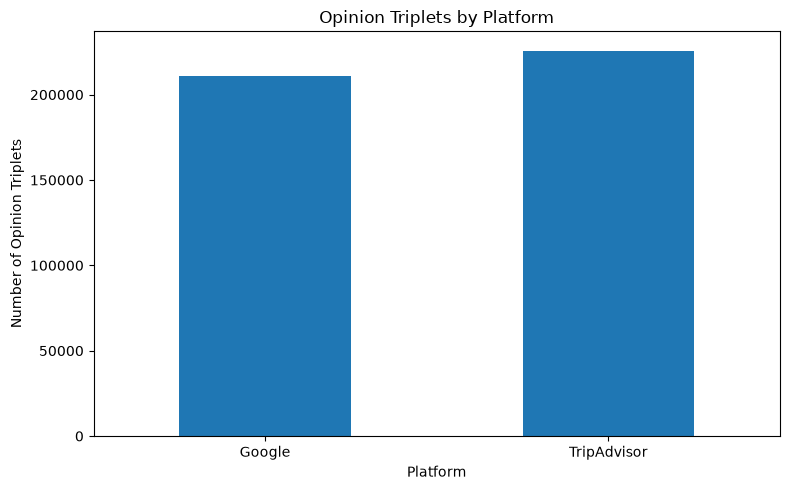

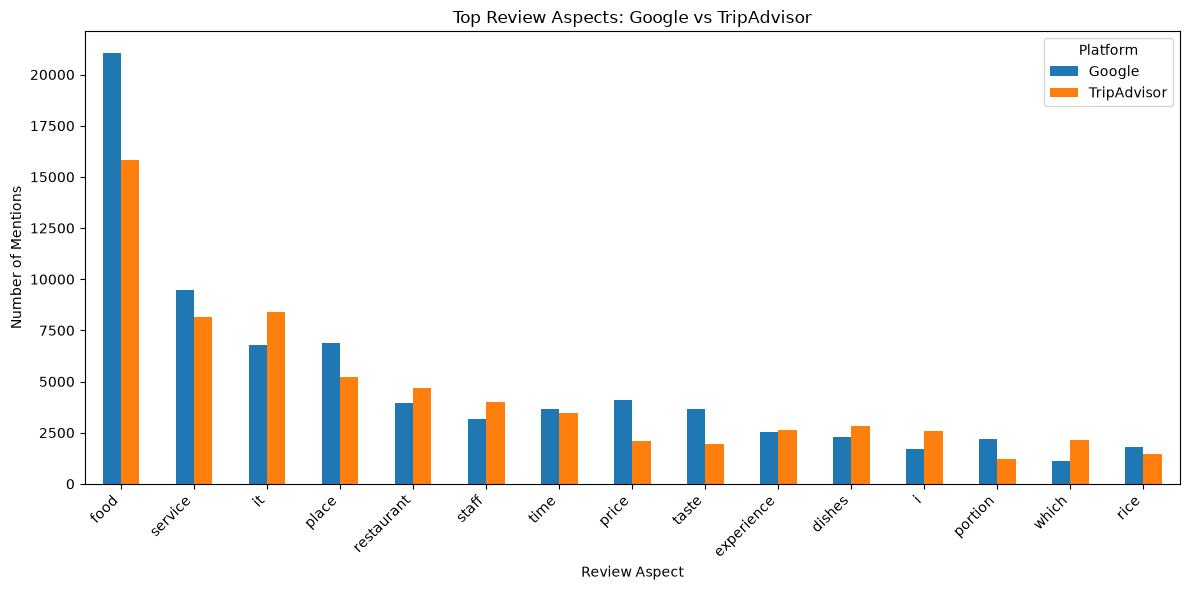


✓ PART 4 COMPLETE!


In [7]:
# ============================================
# PART 4: PLATFORM COMPARISON
# Google vs TripAdvisor
# ============================================

print("=" * 70)
print("PART 4: PLATFORM COMPARISON")
print("=" * 70)

# ------------------------------------------------
# 1. CHECK AVAILABLE COLUMNS
# ------------------------------------------------

print("\nAvailable columns in df:")
print(df.columns.tolist())

print("\nAvailable columns in triplet_df:")
print(triplet_df.columns.tolist())


# ------------------------------------------------
# 2. FIND THE PLATFORM COLUMN
# ------------------------------------------------

possible_platform_columns = [
    'Platform',
    'platform',
    'Source',
    'source',
    'Website',
    'website',
    'Site',
    'site'
]

platform_col = None

for col in possible_platform_columns:
    if col in df.columns:
        platform_col = col
        break

if platform_col is None:
    print("\n⚠ Platform column was not found automatically.")
    print("Please check the column names printed above.")
else:
    print(f"\n✓ Platform column found: {platform_col}")


# ------------------------------------------------
# 3. CHECK PLATFORM VALUES
# ------------------------------------------------

if platform_col is not None:

    print("\nPlatform values:")
    print(df[platform_col].value_counts(dropna=False))


# ------------------------------------------------
# 4. CREATE PLATFORM MAPPING
# ------------------------------------------------

if platform_col is not None:

    # Convert platform names to lowercase
    df['_Platform_Clean'] = (
        df[platform_col]
        .fillna('')
        .astype(str)
        .str.lower()
        .str.strip()
    )

    # Standardise platform names
    df['_Platform_Clean'] = np.select(
        [
            df['_Platform_Clean'].str.contains(
                'google', case=False, na=False
            ),
            df['_Platform_Clean'].str.contains(
                'tripadvisor|trip advisor',
                case=False,
                na=False
            )
        ],
        [
            'Google',
            'TripAdvisor'
        ],
        default='Other'
    )

    print("\nStandardised platform counts:")
    print(df['_Platform_Clean'].value_counts())


# ------------------------------------------------
# 5. CONNECT TRIPLETS TO PLATFORM
# ------------------------------------------------

if platform_col is not None and len(triplet_df) > 0:

    # Make sure Review_ID is numeric
    triplet_df['Review_ID'] = pd.to_numeric(
        triplet_df['Review_ID'],
        errors='coerce'
    )

    # Remove invalid IDs
    triplet_df = triplet_df.dropna(
        subset=['Review_ID']
    ).copy()

    triplet_df['Review_ID'] = (
        triplet_df['Review_ID']
        .astype(int)
    )

    # Map Review_ID to platform
    platform_lookup = df[
        ['_Platform_Clean']
    ].reset_index(drop=True)

    triplet_df['Platform'] = (
        triplet_df['Review_ID']
        .map(platform_lookup['_Platform_Clean'])
    )

    print("\n✓ Platform information added to triplets")

    print("\nTriplets by platform:")
    print(
        triplet_df['Platform']
        .value_counts()
    )


# ------------------------------------------------
# 6. FILTER GOOGLE + TRIPADVISOR
# ------------------------------------------------

if 'Platform' in triplet_df.columns:

    platform_triplets = triplet_df[
        triplet_df['Platform'].isin(
            ['Google', 'TripAdvisor']
        )
    ].copy()

    print("\n" + "=" * 70)
    print("PLATFORM TRIPLET COUNTS")
    print("=" * 70)

    print(
        platform_triplets['Platform']
        .value_counts()
    )


# ------------------------------------------------
# 7. TOP OPINION EXPRESSIONS BY PLATFORM
# ------------------------------------------------

if len(platform_triplets) > 0:

    print("\n" + "=" * 70)
    print("TOP OPINION EXPRESSIONS")
    print("=" * 70)

    for platform in ['Google', 'TripAdvisor']:

        platform_data = platform_triplets[
            platform_triplets['Platform'] == platform
        ]

        print(f"\n--- {platform} ---")

        print(
            platform_data[
                'Opinion_Expression'
            ]
            .value_counts()
            .head(15)
        )


# ------------------------------------------------
# 8. TOP TARGETS / ASPECTS BY PLATFORM
# ------------------------------------------------

if len(platform_triplets) > 0:

    print("\n" + "=" * 70)
    print("TOP REVIEW ASPECTS / TARGETS")
    print("=" * 70)

    for platform in ['Google', 'TripAdvisor']:

        platform_data = platform_triplets[
            platform_triplets['Platform'] == platform
        ]

        print(f"\n--- {platform} ---")

        print(
            platform_data[
                'Target'
            ]
            .value_counts()
            .head(20)
        )


# ------------------------------------------------
# 9. COMPARISON TABLE
# ------------------------------------------------

if len(platform_triplets) > 0:

    comparison = (
        platform_triplets
        .groupby(
            ['Platform', 'Target']
        )
        .size()
        .reset_index(
            name='Mention_Count'
        )
    )

    comparison = comparison.sort_values(
        ['Platform', 'Mention_Count'],
        ascending=[True, False]
    )

    print("\n" + "=" * 70)
    print("PLATFORM ASPECT COMPARISON")
    print("=" * 70)

    display(comparison.head(40))


# ------------------------------------------------
# 10. CREATE SIDE-BY-SIDE COMPARISON
# ------------------------------------------------

if len(platform_triplets) > 0:

    comparison_pivot = (
        comparison
        .pivot_table(
            index='Target',
            columns='Platform',
            values='Mention_Count',
            fill_value=0
        )
        .reset_index()
    )

    # Make sure both columns exist
    if 'Google' not in comparison_pivot.columns:
        comparison_pivot['Google'] = 0

    if 'TripAdvisor' not in comparison_pivot.columns:
        comparison_pivot['TripAdvisor'] = 0

    comparison_pivot['Total'] = (
        comparison_pivot['Google'] +
        comparison_pivot['TripAdvisor']
    )

    comparison_pivot = comparison_pivot.sort_values(
        'Total',
        ascending=False
    )

    print("\n" + "=" * 70)
    print("GOOGLE vs TRIPADVISOR")
    print("=" * 70)

    display(
        comparison_pivot.head(30)
    )


# ------------------------------------------------
# 11. PLATFORM DISTRIBUTION GRAPH
# ------------------------------------------------

if len(platform_triplets) > 0:

    platform_counts = (
        platform_triplets['Platform']
        .value_counts()
        .reindex(
            ['Google', 'TripAdvisor'],
            fill_value=0
        )
    )

    plt.figure(figsize=(8, 5))

    platform_counts.plot(
        kind='bar'
    )

    plt.title(
        'Opinion Triplets by Platform'
    )

    plt.xlabel('Platform')
    plt.ylabel('Number of Opinion Triplets')

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()


# ------------------------------------------------
# 12. TOP ASPECTS COMPARISON GRAPH
# ------------------------------------------------

if len(platform_triplets) > 0:

    top_aspects = (
        comparison_pivot
        .head(15)
        .set_index('Target')
    )

    top_aspects[
        ['Google', 'TripAdvisor']
    ].plot(
        kind='bar',
        figsize=(12, 6)
    )

    plt.title(
        'Top Review Aspects: Google vs TripAdvisor'
    )

    plt.xlabel('Review Aspect')
    plt.ylabel('Number of Mentions')

    plt.xticks(rotation=45, ha='right')

    plt.tight_layout()
    plt.show()


print("\n✓ PART 4 COMPLETE!")

## Part 5: Visualizations 

PART 5: VISUALIZATIONS

Total opinion triplets: 436,541


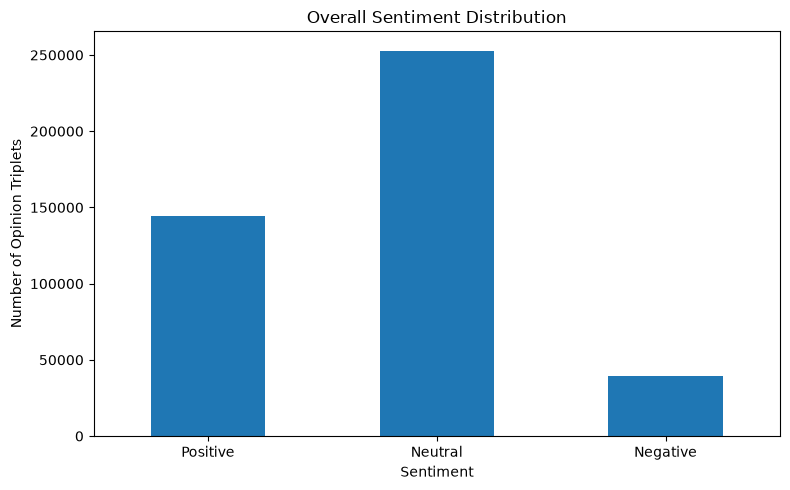


✓ Visualization 1: Overall Sentiment Distribution


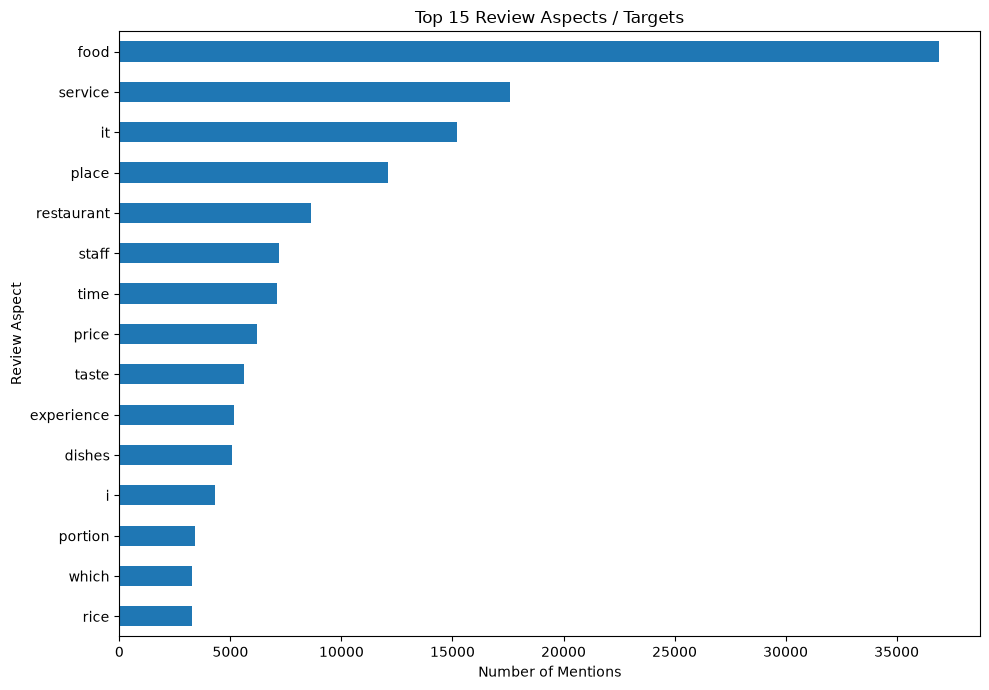

✓ Visualization 2: Top Review Aspects


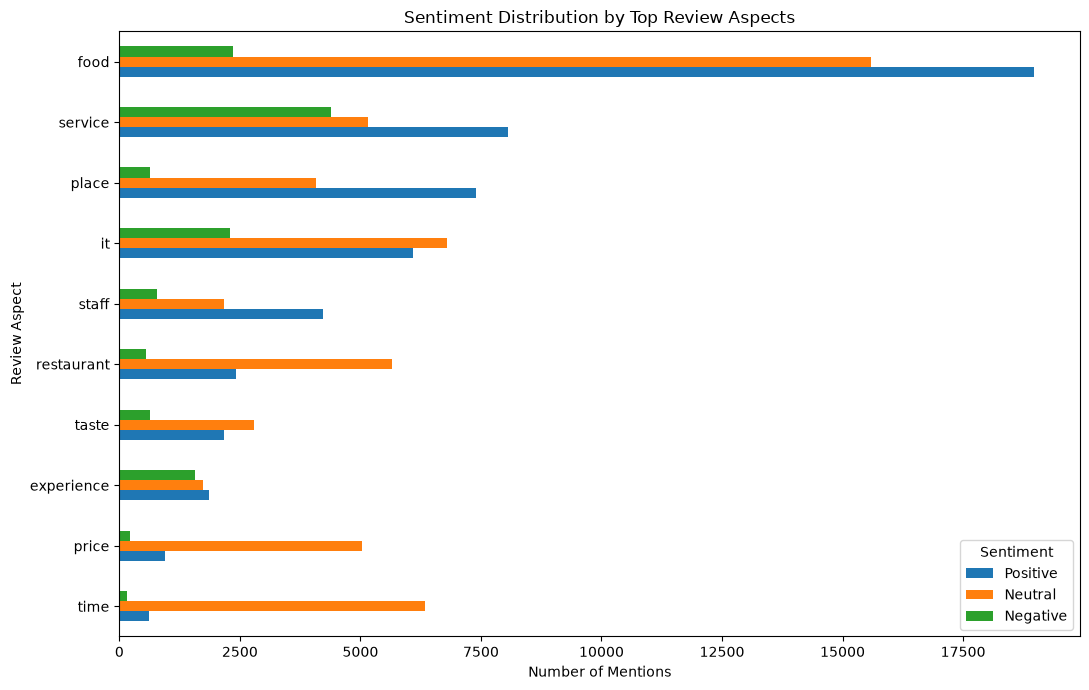

✓ Visualization 3: Sentiment by Aspect


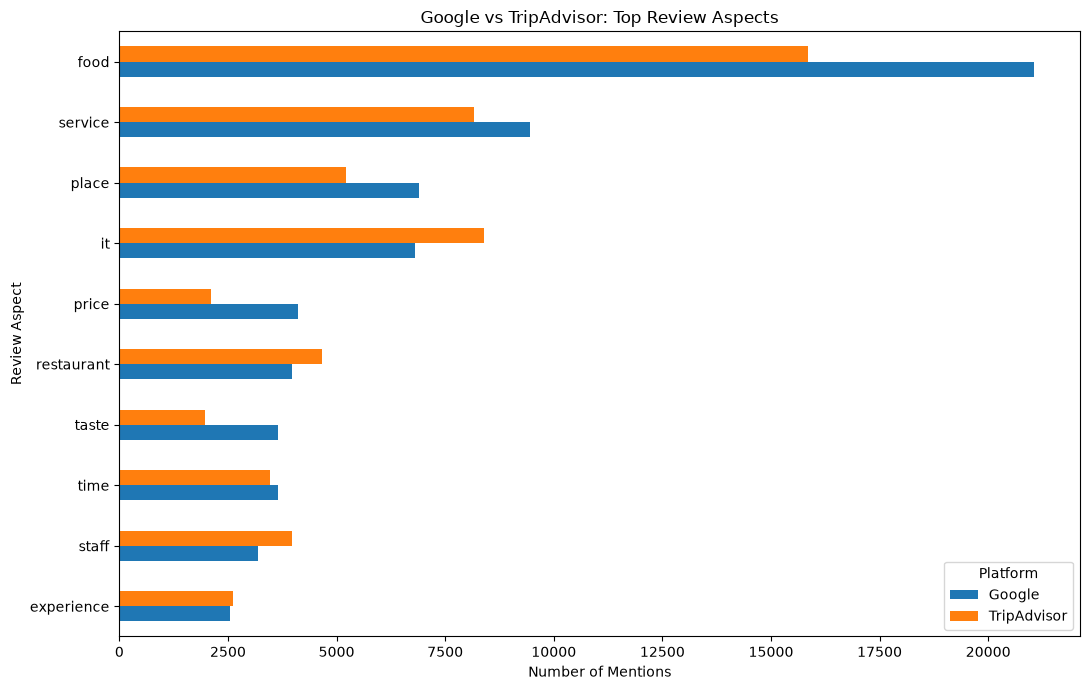

✓ Visualization 4: Google vs TripAdvisor


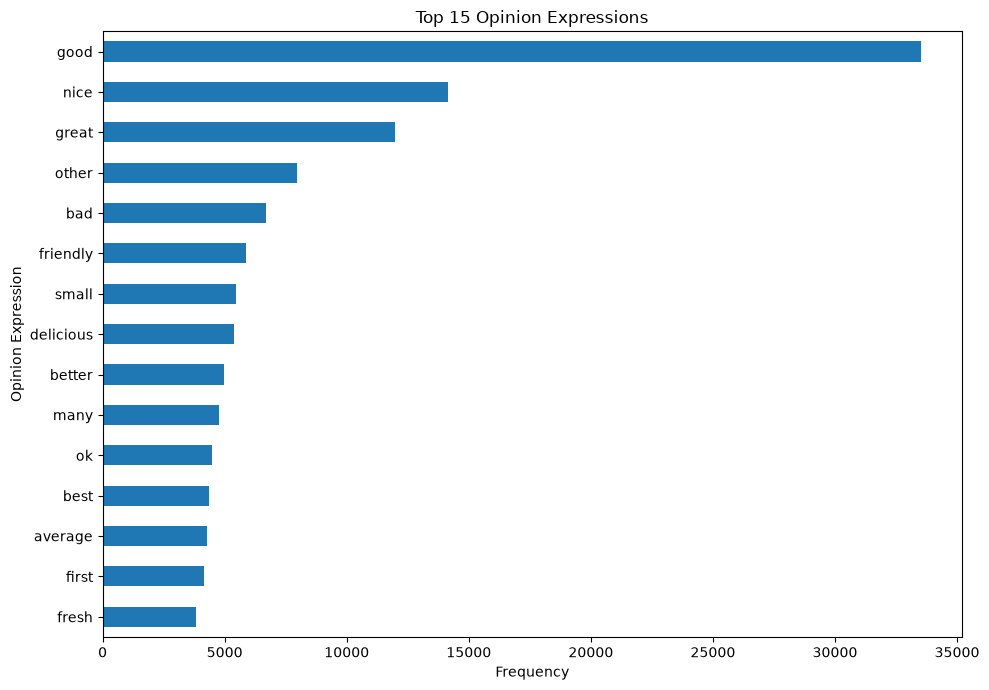

✓ Visualization 5: Top Opinion Expressions

PART 5 COMPLETE!


In [8]:
# ============================================
# PART 5: VISUALIZATIONS
# ============================================

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print("=" * 70)
print("PART 5: VISUALIZATIONS")
print("=" * 70)

# Check data
print(f"\nTotal opinion triplets: {len(triplet_df):,}")

if len(triplet_df) == 0:
    print("⚠ No triplets available for visualization.")
else:

    # ------------------------------------------------
    # 1. OVERALL SENTIMENT DISTRIBUTION
    # ------------------------------------------------
    
    sentiment_counts = (
        triplet_df['Sentiment']
        .value_counts()
        .reindex(['Positive', 'Neutral', 'Negative'], fill_value=0)
    )

    plt.figure(figsize=(8, 5))
    sentiment_counts.plot(kind='bar')

    plt.title('Overall Sentiment Distribution')
    plt.xlabel('Sentiment')
    plt.ylabel('Number of Opinion Triplets')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

    print("\n✓ Visualization 1: Overall Sentiment Distribution")


    # ------------------------------------------------
    # 2. TOP REVIEW ASPECTS / TARGETS
    # ------------------------------------------------

    top_targets = (
        triplet_df['Target']
        .value_counts()
        .head(15)
        .sort_values()
    )

    plt.figure(figsize=(10, 7))
    top_targets.plot(kind='barh')

    plt.title('Top 15 Review Aspects / Targets')
    plt.xlabel('Number of Mentions')
    plt.ylabel('Review Aspect')
    plt.tight_layout()
    plt.show()

    print("✓ Visualization 2: Top Review Aspects")


    # ------------------------------------------------
    # 3. SENTIMENT BY ASPECT
    # ------------------------------------------------

    top_target_names = (
        triplet_df['Target']
        .value_counts()
        .head(10)
        .index
    )

    aspect_sentiment = (
        triplet_df[
            triplet_df['Target'].isin(top_target_names)
        ]
        .groupby(['Target', 'Sentiment'])
        .size()
        .unstack(fill_value=0)
    )

    # Make sure all sentiment columns exist
    for sentiment in ['Positive', 'Neutral', 'Negative']:
        if sentiment not in aspect_sentiment.columns:
            aspect_sentiment[sentiment] = 0

    aspect_sentiment = aspect_sentiment[
        ['Positive', 'Neutral', 'Negative']
    ]

    aspect_sentiment = aspect_sentiment.sort_values(
        'Positive',
        ascending=True
    )

    aspect_sentiment.plot(
        kind='barh',
        figsize=(11, 7)
    )

    plt.title('Sentiment Distribution by Top Review Aspects')
    plt.xlabel('Number of Mentions')
    plt.ylabel('Review Aspect')
    plt.tight_layout()
    plt.show()

    print("✓ Visualization 3: Sentiment by Aspect")


    # ------------------------------------------------
    # 4. GOOGLE vs TRIPADVISOR
    # ------------------------------------------------

    if 'Platform' in triplet_df.columns:

        platform_data = triplet_df[
            triplet_df['Platform'].isin(
                ['Google', 'TripAdvisor']
            )
        ].copy()

        if len(platform_data) > 0:

            # Get most commonly mentioned aspects
            top_platform_targets = (
                platform_data['Target']
                .value_counts()
                .head(10)
                .index
            )

            platform_aspects = (
                platform_data[
                    platform_data['Target'].isin(
                        top_platform_targets
                    )
                ]
                .groupby(['Target', 'Platform'])
                .size()
                .unstack(fill_value=0)
            )

            if 'Google' not in platform_aspects.columns:
                platform_aspects['Google'] = 0

            if 'TripAdvisor' not in platform_aspects.columns:
                platform_aspects['TripAdvisor'] = 0

            platform_aspects = platform_aspects[
                ['Google', 'TripAdvisor']
            ]

            platform_aspects = platform_aspects.sort_values(
                'Google',
                ascending=True
            )

            platform_aspects.plot(
                kind='barh',
                figsize=(11, 7)
            )

            plt.title(
                'Google vs TripAdvisor: Top Review Aspects'
            )
            plt.xlabel('Number of Mentions')
            plt.ylabel('Review Aspect')
            plt.tight_layout()
            plt.show()

            print(
                "✓ Visualization 4: Google vs TripAdvisor"
            )

        else:
            print(
                "⚠ No Google/TripAdvisor data available."
            )

    else:
        print(
            "⚠ Platform column not found. "
            "Skipping Google vs TripAdvisor visualization."
        )


    # ------------------------------------------------
    # 5. TOP OPINION EXPRESSIONS
    # ------------------------------------------------

    top_opinions = (
        triplet_df['Opinion_Expression']
        .value_counts()
        .head(15)
        .sort_values()
    )

    plt.figure(figsize=(10, 7))
    top_opinions.plot(kind='barh')

    plt.title('Top 15 Opinion Expressions')
    plt.xlabel('Frequency')
    plt.ylabel('Opinion Expression')
    plt.tight_layout()
    plt.show()

    print("✓ Visualization 5: Top Opinion Expressions")


    # ------------------------------------------------
    # SUMMARY
    # ------------------------------------------------

    print("\n" + "=" * 70)
    print("PART 5 COMPLETE!")
    print("=" * 70)

## Export Useful Data

In [11]:
# ============================================
# PART 6: EXPORT DATA FOR RESTAURANT RANKING
# ============================================

print("=" * 70)
print("PART 6: PREPARING & EXPORTING RANKING DELIVERABLES")
print("=" * 70)

# ------------------------------------------------
# 1. MAP Extracted Targets to 7 Aspect Categories
# ------------------------------------------------

# Create a reverse dictionary for fast lookup: {keyword: category}
keyword_to_category = {}
for category, keywords in aspect_keywords.items():
    for kw in keywords:
        keyword_to_category[kw.lower()] = category

def categorize_target(target):
    target_clean = str(target).lower().strip()
    return keyword_to_category.get(target_clean, 'Other')

# Assign category to each extracted triplet
triplet_df['Category'] = triplet_df['Target'].apply(categorize_target)

print(f"✓ Mapped triplets to categories:")
print(triplet_df['Category'].value_counts())

# Filter out 'Other' for aspect-specific scoring
aspect_sentiment_df = triplet_df[triplet_df['Category'] != 'Other'].copy()


# ------------------------------------------------
# 2. ATTACH RESTAURANT METADATA TO TRIPLETS
# ------------------------------------------------

# Identify necessary columns from df to merge back
metadata_cols = ['Restaurant', 'Rating'] if 'Rating' in df.columns else ['Restaurant']

# Ensure Review_ID key aligns with original df index
review_metadata = df[metadata_cols].copy()
review_metadata.index.name = 'Review_ID'

# Merge metadata into aspect triplets
aspect_sentiment_df = aspect_sentiment_df.merge(
    review_metadata, 
    left_on='Review_ID', 
    right_index=True, 
    how='left'
)


# ------------------------------------------------
# 3. BUILD REVIEW-LEVEL DATASET WITH ASPECT SCORES
# ------------------------------------------------

# Compute average aspect sentiment score per review per category
review_aspect_pivot = aspect_sentiment_df.groupby(
    ['Review_ID', 'Category']
)['Polarity_Score'].mean().unstack()

# Prefix columns for clarity
review_aspect_pivot.columns = [f'Aspect_Score_{col}' for col in review_aspect_pivot.columns]

# Merge aspect scores directly back into main review DataFrame
df_ranked_prep = df.merge(
    review_aspect_pivot, 
    left_index=True, 
    right_index=True, 
    how='left'
)


# ------------------------------------------------
# 4. BUILD RESTAURANT-LEVEL AGGREGATED SUMMARY
# ------------------------------------------------

aspect_cols = [col for col in df_ranked_prep.columns if col.startswith('Aspect_Score_')]

# Dynamically set aggregation dictionary
agg_dict = {'Review': 'count'}
if 'Rating' in df_ranked_prep.columns:
    agg_dict['Rating'] = 'mean'

for col in aspect_cols:
    agg_dict[col] = 'mean'

restaurant_aspect_summary = df_ranked_prep.groupby('Restaurant').agg(agg_dict).reset_index()

# Rename columns clearly for ranking algorithms
rename_dict = {'Review': 'Review_Count', 'Rating': 'Avg_Star_Rating'}
for col in aspect_cols:
    rename_dict[col] = col.replace('Aspect_Score_', 'Avg_Aspect_')

restaurant_aspect_summary = restaurant_aspect_summary.rename(columns=rename_dict)


# ------------------------------------------------
# 5. SAVE CSV DELIVERABLES
# ------------------------------------------------

export_dir = os.path.join(master_dir, "outputs")
os.makedirs(export_dir, exist_ok=True)

# Deliverable 1: Review-level enriched dataset
reviews_out_path = os.path.join(export_dir, "reviews_with_absa_opinions.csv")
df_ranked_prep.to_csv(reviews_out_path, index=False)
print(f"✓ Saved: {reviews_out_path}")

# Deliverable 2: Restaurant-level aggregated ratings and aspect averages
restaurant_out_path = os.path.join(export_dir, "restaurant_aspect_summary.csv")
restaurant_aspect_summary.to_csv(restaurant_out_path, index=False)
print(f"✓ Saved: {restaurant_out_path}")

# Deliverable 3: Extracted sentiment pairs with category lookup
triplets_out_path = os.path.join(export_dir, "absa_sentiment_pairs.csv")
aspect_sentiment_df.to_csv(triplets_out_path, index=False)
print(f"✓ Saved: {triplets_out_path}")

print("\n✓ ALL RANKING DELIVERABLES EXPORTED SUCCESSFULLY!")

PART 6: PREPARING & EXPORTING RANKING DELIVERABLES
✓ Mapped triplets to categories:
Category
Other           308262
Food             72681
Service          26961
Price             8636
Waiting Time      8145
Ambience          8145
Location          3340
Cleanliness        371
Name: count, dtype: int64
✓ Saved: c:\Users\user\Downloads\social_computing_assignment\outputs\reviews_with_absa_opinions.csv
✓ Saved: c:\Users\user\Downloads\social_computing_assignment\outputs\restaurant_aspect_summary.csv
✓ Saved: c:\Users\user\Downloads\social_computing_assignment\outputs\absa_sentiment_pairs.csv

✓ ALL RANKING DELIVERABLES EXPORTED SUCCESSFULLY!
